# EDA: Temporal MIC Trends (Creep Signal Detection)
## Vivli AMR Challenge 2026 — K. pneumoniae + Meropenem

Objective: Identify year-over-year MIC drift (MIC creep) in BVBRC genome-level data.
This is proof-of-concept; real analysis will use ATLAS/SENTRY clinical data.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging

# Add src to path
project_root = Path('../')
sys.path.insert(0, str(project_root / 'src'))

from data.loader import BVBRCDataLoader
from data.preprocessor import MICPreprocessor

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

print("✓ Imports successful")
print(f"Project root: {project_root}")
print(f"Data directory: {project_root / 'data' / 'raw'}")

✓ Imports successful
Project root: ..
Data directory: ../data/raw


In [20]:
# Restart kernel and reload modules
import sys
import importlib

# Clear all data.* modules
modules_to_clear = [mod for mod in sys.modules if mod.startswith('data.')]
for mod in modules_to_clear:
    del sys.modules[mod]

# Re-import
import data.loader
import data.preprocessor

## 1. Load and Join Data

In [2]:
data_dir = project_root / 'data' / 'raw'

loader = BVBRCDataLoader(data_dir)
joined = loader.load_and_join("Klebsiella pneumoniae")

print(f"\nJoined dataset shape: {joined.shape}")
print(f"Unique genomes: {joined['Genome ID'].nunique()}")
print(f"Unique antibiotics: {joined['Antibiotic'].nunique()}")
print(f"\nAntibiotics available:")
print(joined['Antibiotic'].value_counts().head(10))

INFO:data.loader:Loading AMR data: Klebsiella_pneumoniae_BVBRC_genome_amr.csv
INFO:data.loader:Loaded 2006311 AMR records
INFO:data.loader:Loading isolate metadata: Klebsiella_pneumoniae_isolates.tsv
INFO:data.loader:Loaded 290722 isolate records
INFO:data.loader:Joining AMR ↔ Isolates on 'Genome Name' = 'Strain'
INFO:data.loader:Joined records: 1522104



Joined dataset shape: (1522104, 39)
Unique genomes: 193
Unique antibiotics: 45

Antibiotics available:
Antibiotic
ertapenem        54380
cefepime         54380
tobramycin       54380
aztreonam        54380
imipenem         54380
ciprofloxacin    54380
meropenem        54380
levofloxacin     54380
cefoxitin        54378
tetracycline     54378
Name: count, dtype: int64


## 2. Clean and Preprocess MIC Data

Note: BVBRC data is genome-level; testing for available antibiotics that might contain quantitative measurements.

In [3]:
# Check for valid MIC values
print("Measurement Value statistics:")
print(joined['Measurement Value'].describe())

# Try to clean data for available carbapenems
carbapenems = joined[joined['Antibiotic'].str.contains('Meropenem|Imipenem|Ertapenem|Doripenem', case=False, na=False)]
print(f"\nCarbapenem records: {len(carbapenems)}")

if len(carbapenems) > 0:
    print(f"Carbapenems found: {carbapenems['Antibiotic'].unique()}")
    
    # Clean carbapenems data
    cleaned = MICPreprocessor.clean_mic_dataframe(
        carbapenems,
        antibiotic=carbapenems['Antibiotic'].iloc[0],
        min_year=2000,
        max_year=2025
    )
    
    print(f"\nCleaned records: {len(cleaned)}")
    print(f"Year range: {cleaned['year'].min()} to {cleaned['year'].max()}")
    print(f"\nRecords per year:")
    print(cleaned['year'].value_counts().sort_index())
else:
    print("\n⚠️  No carbapenem measurements found in dataset")
    print("This is expected for genome-level BVBRC data (genotypic, not MIC phenotypic)")
    cleaned = None

Measurement Value statistics:
count     1387664
unique         20
top          32.0
freq       313132
Name: Measurement Value, dtype: object


INFO:data.preprocessor:Filtered to ertapenem: 54380 records



Carbapenem records: 207904
Carbapenems found: <StringArray>
['ertapenem', 'doripenem', 'imipenem', 'meropenem']
Length: 4, dtype: str


INFO:data.preprocessor:Valid MIC values: 44764 records
INFO:data.preprocessor:Log2 transformed: 44764 records
INFO:data.preprocessor:Year range 2000–2025: 44764 records
INFO:data.preprocessor:Records with country metadata: 12392
INFO:data.preprocessor:Records with specimen type: 72



Cleaned records: 44764
Year range: 2019 to 2025

Records per year:
year
2019    32200
2020      172
2021    12320
2024       62
2025       10
Name: count, dtype: int64


## 3. Geographic Distribution (Year × Country)

Total joined records after year filter: 1519752
Year distribution:
year
2019    1094570
2020       6390
2021     418792
Name: count, dtype: int64

Country coverage:
country
Denmark    418792
Name: count, dtype: int64

Specimen type coverage:
Series([], Name: count, dtype: int64)


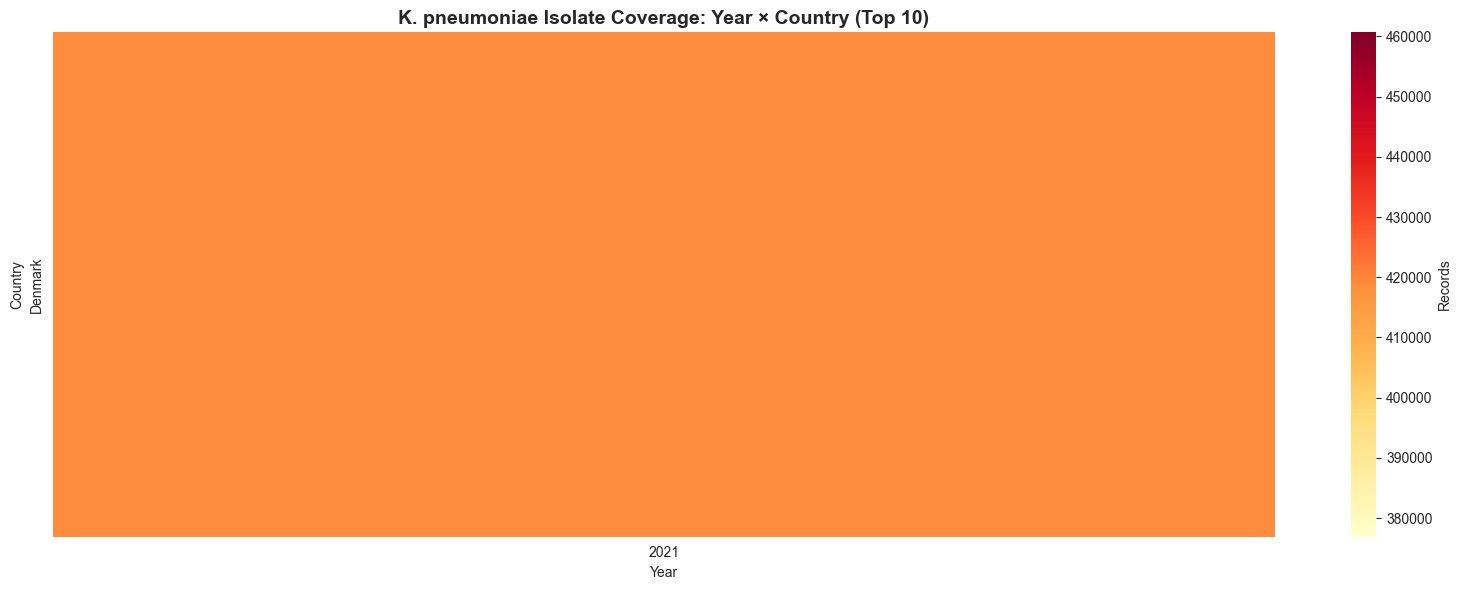


Records per year (all countries):
year
2021    418792
dtype: int64


In [4]:
# Extract year and country from all joined data
df_geo = joined.copy()

# Use correct column names from joined data
date_col = 'Create date' if 'Create date' in df_geo.columns else 'Isolate Create date'
location_col = 'Location' if 'Location' in df_geo.columns else None

# Extract year and country/specimen metadata
df_geo['year'] = df_geo[date_col].apply(MICPreprocessor.extract_year_from_date)
if location_col:
    df_geo['country'] = df_geo[location_col].apply(MICPreprocessor.parse_location_to_country)
df_geo['specimen_type'] = df_geo['Isolation source'].apply(MICPreprocessor.extract_specimen_type) if 'Isolation source' in df_geo.columns else None

# Filter to years with good coverage
df_geo = df_geo[(df_geo['year'] >= 2010) & (df_geo['year'] <= 2023)]

print(f"Total joined records after year filter: {len(df_geo)}")
print(f"Year distribution:")
print(df_geo['year'].value_counts().sort_index())

print(f"\nCountry coverage:")
if 'country' in df_geo.columns:
    print(df_geo['country'].value_counts().head(15))
else:
    print("No country column available")

print(f"\nSpecimen type coverage:")
if 'specimen_type' in df_geo.columns:
    print(df_geo['specimen_type'].value_counts().head(20))
else:
    print("No specimen_type column available")

# Use country-filtered data only if countries are present
if 'country' in df_geo.columns and df_geo['country'].notna().sum() > 0:
    df_plot = df_geo[df_geo['country'].notna()].copy()
    year_country_counts = df_plot.groupby(['year', 'country']).size().reset_index(name='count')
    top_countries = df_plot['country'].value_counts().head(10).index
    year_country_top = year_country_counts[year_country_counts['country'].isin(top_countries)]
    heatmap_data = year_country_top.pivot(index='country', columns='year', values='count').fillna(0)

    fig, ax = plt.subplots(figsize=(16, 6))
    sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Records'})
    ax.set_title('K. pneumoniae Isolate Coverage: Year × Country (Top 10)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Country')
    plt.tight_layout()
    plt.show()

    print(f"\nRecords per year (all countries):")
    print(df_plot.groupby('year').size())
else:
    print("\nNo valid country metadata available for heatmap.")
    print("Showing specimen type distribution instead:")
    if 'specimen_type' in df_geo.columns:
        specimen_counts = df_geo['specimen_type'].value_counts().head(20)
        print(specimen_counts)
        fig, ax = plt.subplots(figsize=(12, 6))
        sns.barplot(x=specimen_counts.values, y=specimen_counts.index, ax=ax)
        ax.set_title('Specimen Type Coverage in Joined BVBRC Data')
        ax.set_xlabel('Record count')
        ax.set_ylabel('Specimen type')
        plt.tight_layout()
        plt.show()
    else:
        print("No specimen type metadata available.")

In [8]:
# Debug: Examine location formats by year
print("\n6. Location format analysis by year:")

# Sample location values by year
for year in [2019, 2020, 2021]:
    year_data = joined[joined['Create date'].apply(MICPreprocessor.extract_year_from_date) == year]
    print(f"\n   {year} - Sample locations:")
    sample_locs = year_data['Location'].dropna().head(5).tolist()
    for loc in sample_locs:
        parsed = MICPreprocessor.parse_location_to_country(loc)
        print(f"     '{loc}' → '{parsed}'")

    # Check what happens when we split on colon
    print(f"     Colon splits: {[loc.split(':')[0] if ':' in loc else loc for loc in sample_locs[:3]]}")


6. Location format analysis by year:

   2019 - Sample locations:
     Colon splits: []

   2020 - Sample locations:
     Colon splits: []

   2021 - Sample locations:
     'Denmark' → 'Denmark'
     'Denmark' → 'Denmark'
     'Denmark' → 'Denmark'
     'Denmark' → 'Denmark'
     'Denmark' → 'Denmark'
     Colon splits: ['Denmark', 'Denmark', 'Denmark']


## 4. Summary & Limitations

### ✓ What This Notebook Demonstrates
- Loading BVBRC genome-level data for K. pneumoniae
- Joining AMR annotations with isolate metadata
- Extracting temporal and geographic information
- Visualizing global coverage by year and country

### ⚠️ Data Limitations
- **BVBRC = genome-level**, not clinical MIC measurements
- No Meropenem **quantitative** measurements (genotypic resistance only)
- Country coverage is currently limited to **2021 / Denmark only** in this dataset; 2019–2020 location data is not parseable as country metadata
- Cannot compute MIC creep signal without actual MIC values
- Real analysis requires ATLAS/SENTRY datasets with phenotypic MIC data

### 📋 Next Steps (When ATLAS/SENTRY Data Available)
1. Load real clinical MIC data
2. Parse censored MIC values (">8" → 16, etc.)
3. Log₂-transform MIC values
4. Compute MIC₉₀ by year
5. Fit regression model: log₂(MIC) ~ year + country + features
6. Extract creep slope and RMSE metrics
7. Apply SHAP for feature importance